# Predictions: Heart Diseases

Prediction of heart disease given medical informartion. 

## Libraries

In [29]:
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

pd.set_option('display.max_colwidth', None)

In [30]:
MAX_DATASET_SAMPLES = 10000 # Datasets will the capped to this sample_size to keep experiments fast 

## Import Data

In [31]:
datasets = [
    {
        "name": "Mobile Health Human Behavior Analysis",
        "path": "data/mhealth_raw_data.csv",
        # "path_train": "data/",
        # "path_test": "data/",
        "features_numerical": [], # [ All of them, except subject and Activity ]
        "features_categorical": [],
        "target": "Activity",
    },

    {
        "name": "Human Activity Recognition Trondheim (HARTH)",
        # "path": #,
        "path_train": "data/har_trondheim/train.csv",
        "path_test": "data/har_trondheim/test.csv",
        "features_numerical": [], # [ All of them, except Activity ]
        "features_categorical": [],
        "target": "Activity",
    },

    {
        "name": "Human Activity Recognition with Smartphones",
        # "path": #,
        "path_train": "data/har_with_smartphones/train.csv",
        "path_test": "data/har_with_smartphones/test.csv",
        "features_numerical": [], # [ All of them, except subject and Activity ]
        "features_categorical": [],
        "target": "Activity",
    },
]

for dataset in datasets: 
    file_path = dataset["path"] if "path" in dataset else dataset["path_train"]
    columns = pd.read_csv(file_path, nrows=0).columns.tolist()
    dataset["features_numerical"] = [f for f in columns if f not in ("subject", dataset["target"])]

pprint(datasets) 

[{'features_categorical': [],
  'features_numerical': ['alx',
                         'aly',
                         'alz',
                         'glx',
                         'gly',
                         'glz',
                         'arx',
                         'ary',
                         'arz',
                         'grx',
                         'gry',
                         'grz'],
  'name': 'Mobile Health Human Behavior Analysis',
  'path': 'data/mhealth_raw_data.csv',
  'target': 'Activity'},
 {'features_categorical': [],
  'features_numerical': ['Feature_1',
                         'Feature_2',
                         'Feature_3',
                         'Feature_4',
                         'Feature_5',
                         'Feature_6'],
  'name': 'Human Activity Recognition Trondheim (HARTH)',
  'path_test': 'data/har_trondheim/test.csv',
  'path_train': 'data/har_trondheim/train.csv',
  'target': 'Activity'},
 {'features_categorical': [],
  'f

In [32]:
# Show Data sizes:
for dataset in datasets:
    print(dataset["name"])
    if "path" in dataset: 
        df = pd.read_csv(dataset["path"])
        print("Shape:", df.shape)
    else:
        df = pd.read_csv(dataset["path_train"])
        print("Shape Train:", df.shape)
        df = pd.read_csv(dataset["path_test"])
        print("Shape Test:", df.shape)

Mobile Health Human Behavior Analysis
Shape: (1215745, 14)
Human Activity Recognition Trondheim (HARTH)
Shape Train: (5267996, 7)
Shape Test: (1193332, 7)
Human Activity Recognition with Smartphones
Shape Train: (7352, 563)
Shape Test: (2947, 563)


In [33]:
dataset_path = datasets[0]["path"]
df = pd.read_csv(dataset_path)
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.449020,-1.01030,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.449020,-1.01030,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.449020,-1.01030,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.456860,-1.00820,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.456860,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215740,1.7849,-9.8287,0.29725,-0.341370,-0.90056,-0.61493,-3.7198,-8.9071,0.294230,0.041176,-0.99384,-0.480600,0,subject10
1215741,1.8687,-9.8766,0.46236,-0.341370,-0.90056,-0.61493,-3.7160,-8.7455,0.448140,0.041176,-0.99384,-0.480600,0,subject10
1215742,1.6928,-9.9290,0.16631,-0.341370,-0.90056,-0.61493,-3.8824,-9.1155,0.450480,0.041176,-0.99384,-0.480600,0,subject10
1215743,1.5279,-9.6306,0.30458,-0.341370,-0.90056,-0.61493,-3.5564,-9.1441,0.594880,0.041176,-0.99384,-0.480600,0,subject10


## EDA

In [34]:
def describe_dataframe(df:pd.DataFrame)->pd.DataFrame:
    df_describe = df.describe()
    df_describe.loc['dtype'] = df_describe.dtypes
    df_describe.loc['null_count'] = df_describe.isnull().sum()
    print("df.shape:", df.shape)
    return df_describe

describe_dataframe(df)

df.shape: (1215745, 14)


,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity
count,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0
mean,1.4942,-9.692878,-0.954806,-0.001599,-0.616632,-0.158781,-3.713413,-5.805526,2.39388,-0.276106,-0.466434,0.266633,1.741465
std,3.826485,4.171303,5.461803,0.491217,0.354641,0.546798,4.763586,5.757639,3.876503,0.527689,0.555551,0.56438,3.283679
min,-22.146,-19.619,-19.373,-2.1466,-7.7899,-2.6267,-22.361,-18.972,-18.239,-8.3392,-3.5708,-2.6897,0.0
25%,0.14131,-10.201,-2.6494,-0.43599,-0.81801,-0.59332,-6.076,-9.4042,0.12965,-0.70588,-0.89733,-0.23707,0.0
50%,1.3089,-9.6703,-0.016456,-0.014842,-0.70732,-0.19057,-2.9776,-7.4615,1.9281,-0.3549,-0.6345,0.30172,0.0
75%,2.5758,-9.0422,1.3013,0.44898,-0.54034,0.3222,-1.1937,-2.5339,4.9147,0.096078,-0.10678,0.77802,2.0
max,20.054,21.161,25.015,60.484,2.0113,2.7701,19.864,22.191,25.741,3.3196,1.5565,2.75,12.0
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
null_count,0,0,0,0,0,0,0,0,0,0,0,0,0


## Define Model

In [35]:
# Suppress onehot transformation warnings
# import warnings
# import re
# original_showwarning = warnings.showwarning
# def custom_showwarning(message, category, filename, lineno, file=None, line=None):
#     if re.match(r"Found unknown categories in columns \[\d+\] during transform\. These unknown categories will be encoded as all zeros", str(message)):
#         return  # Suppress the specific warning
#     original_showwarning(message, category, filename, lineno, file, line)
# warnings.showwarning = custom_showwarning

In [36]:
from sklearn import set_config

# Increase the diagram rendering size
set_config(display='diagram')  # Ensure the pipeline is displayed as a diagram
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (20, 8)  # Adjust the size as needed

In [37]:
from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestClassifier

def create_pipeline(dataset:dict, classifier:BaseEstimator)->Pipeline:

    features_numerical = dataset["features_numerical"]
    features_categorical = dataset["features_categorical"]
    target = dataset['target']
    features_all = features_numerical+features_categorical

    numerical_pipeline = Pipeline(steps=[
        # ('impute', SimpleImputer(strategy='mean')),
        ('scale', StandardScaler())
    ])
    categorical_pipeline = Pipeline(steps=[
        # ('impute', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
    ])
    column_transformer = ColumnTransformer(transformers=[
        ('numerical', numerical_pipeline, features_numerical),
        # ('categorical', categorical_pipeline, features_categorical)
    ])
    pipeline = Pipeline(steps=[
        ('preprocessor', column_transformer),
        ('classifier', classifier)
    ])
    
    return pipeline

# pipeline example
from xgboost import XGBClassifier
create_pipeline(datasets[0], XGBClassifier())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['alx', 'aly', 'alz', 'glx',
                                                   'gly', 'glz', 'arx', 'ary',
                                                   'arz', 'grx', 'gry',
                                                   'grz'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [38]:
from sklearn.base import BaseEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier


classifiers = [
    # SVC(probability=True),
    KNeighborsClassifier(),
    LogisticRegression(n_jobs=-1),
    # MLPClassifier(max_iter=200),
    RandomForestClassifier(n_jobs=-1),
    ExtraTreesClassifier(n_jobs=-1),
    # GradientBoostingClassifier(),
    XGBClassifier(n_jobs=-1)
    # paper
    # StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)),    ('rf', RandomForestClassifier(n_jobs=-1))], final_estimator=LogisticRegression()),
    # StackingClassifier(n_jobs=-1, estimators=[('svm', SVC(probability=True)),           ('mlp', MLPClassifier(max_iter=1000))], final_estimator=LogisticRegression()),
    # StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)),    ('mlp', MLPClassifier(max_iter=1000))], final_estimator=LogisticRegression()),
    # # Arpitha
    # StackingClassifier(n_jobs=-1, estimators=[('knn', KNeighborsClassifier(n_jobs=-1)), ('gb', GradientBoostingClassifier())], final_estimator=LogisticRegression()),
    # StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)), ('gb', GradientBoostingClassifier())], final_estimator=LogisticRegression()),
    # StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)), ('knn', KNeighborsClassifier(n_jobs=-1))], final_estimator=LogisticRegression()),

]

In [39]:
create_pipeline(datasets[0], StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)), ('gb', GradientBoostingClassifier())], final_estimator=LogisticRegression()))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['alx', 'aly', 'alz', 'glx',
                                                   'gly', 'glz', 'arx', 'ary',
                                                   'arz', 'grx', 'gry',
                                                   'grz'])])),
                ('classifier',
                 StackingClassifier(estimators=[('lr',
                                                 LogisticRegression(n_jobs=-1)),
                                                ('gb',
                                                 GradientBoostingClassifier())],
                                    final_estimator=LogisticRegression(),
                                    n_jobs=-1))])

## Training

In [40]:
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

results = {}

for dataset in datasets:
    dataset_name = dataset["name"]
    results[dataset_name] = {}

    # Load Data
    if "path" in dataset:
        df = pd.read_csv(dataset['path'])
    elif "path_train" in dataset:
        df = pd.read_csv(dataset['path_train'])
    else: 
        raise ValueError("Missing path")
    
    print(40 * "##")
    print("Dataset:", dataset["name"])
    print("original data shape:", df.shape)

    # Subsample Data
    if len(df) > MAX_DATASET_SAMPLES:
        df = df.sample(n=MAX_DATASET_SAMPLES, replace=False, random_state=42)

    features_numerical = dataset["features_numerical"]
    features_categorical = dataset["features_categorical"]
    target = dataset['target']
    features_all = features_numerical + features_categorical

    X = df[features_all]
    y = df[target]

    # Cross-validation setup
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    for classifier in classifiers:
        classifier_name = str(classifier).split("(")[0]
        results[dataset_name][classifier_name] = {}

        accuracies = []
        f1_scores = []
        # auc_scores = []
        all_y_true = []
        all_y_pred = []

        for train_index, val_index in tqdm(skf.split(X, y)):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            Y_train, Y_val = y.iloc[train_index], y.iloc[val_index]

            # Encode y before fitting. (XGBoost compatibility)
            le = LabelEncoder()
            Y_train = le.fit_transform(Y_train)
            Y_val = le.transform(Y_val)

            # Create pipeline
            pipeline = create_pipeline(dataset, classifier)

            # Train and predict
            pipeline.fit(X_train, Y_train)
            y_pred_val = pipeline.predict(X_val)
            # y_pred_val = le.inverse_transform(y_pred_val)
            # y_prob_val = pipeline.predict_proba(X_val)  # Only for AUC
                    # Collect predictions
            all_y_true.extend(Y_val)
            all_y_pred.extend(y_pred_val)

            # Metrics
            accuracies.append(accuracy_score(Y_val, y_pred_val))
            f1_scores.append(f1_score(Y_val, y_pred_val, average='weighted'))
            # auc_scores.append(roc_auc_score(Y_val, y_prob_val, multi_class="ovo"))

        # Store averaged metrics
        accuracy = np.mean(accuracies)
        f1 = np.mean(f1_scores)
        conf_matrix = confusion_matrix(all_y_true, all_y_pred)

        results[dataset_name][classifier_name]["accuracy"] = accuracy
        results[dataset_name][classifier_name]["f1"] = f1
        results[dataset_name][classifier_name]["confusion_matrix"] = conf_matrix

        print(f"{classifier_name} average acc: {accuracy:.4f}")
        print(f"{classifier_name} average f1: {f1:.4f}")

        # auc = np.mean(auc_scores)
        # results[dataset_name][classifier_name]["auc"] = auc
        # print(f"{classifier} average auc: {auc:.4f}")


################################################################################
Dataset: Mobile Health Human Behavior Analysis
original data shape: (1215745, 14)


10it [00:01,  6.07it/s]


KNeighborsClassifier average acc: 0.8091
KNeighborsClassifier average f1: 0.8041


10it [00:19,  1.91s/it]


LogisticRegression average acc: 0.7325
LogisticRegression average f1: 0.6479


...

RandomForestClassifier average acc: 0.9830
RandomForestClassifier average f1: 0.9830


10it [00:06,  1.62it/s]


ExtraTreesClassifier average acc: 0.9875
ExtraTreesClassifier average f1: 0.9875


10it [02:35, 15.54s/it]

XGBClassifier average acc: 0.9932
XGBClassifier average f1: 0.9932


In [41]:
results

{'Mobile Health Human Behavior Analysis': {'KNeighborsClassifier': {'accuracy': np.float64(0.8090999999999999),
   'f1': np.float64(0.8041215895793252),
   'confusion_matrix': array([[6295,  106,  116,   80,   84,   42,   69,   93,   75,  110,   68,
             59,   11],
          [  18,  218,    0,    0,    0,    0,    0,    0,    0,    0,    0,
              0,    0],
          [  26,    0,  231,    0,    0,    0,    0,    0,    0,    0,    0,
              0,    0],
          [  19,    0,    0,  255,    0,    0,    0,    0,    0,    0,    0,
              0,    0],
          [ 131,    0,    0,    0,  104,    0,    1,    0,    1,    0,    0,
              0,    0],
          [ 153,    0,    0,    0,   10,   75,    2,    0,    8,    0,    0,
              0,    0],
          [  84,    1,    0,    0,    0,    0,  151,    0,    1,    0,    0,
              0,    0],
          [  95,    0,    0,    0,    0,    0,    3,  143,    0,    0,    0,
              0,    0],
          [  86,   

In [54]:
def format_results(results_dict:dict)->pd.DataFrame:
    """
    NOTE: Docstring created with ChatGPT, edited by a human
    Converts a nested dictionary of results into a DataFrame with Multi-Index columns.
    
    Parameters:
    - results_dict (dict): Nested dictionary where the first level keys are datasets, 
      the second level keys are models, and the leaf values are dictionaries of metrics.
      
    Returns:
    - pd.DataFrame: A DataFrame with Multi-Index columns for datasets and models, 
      and rows for metrics.
    """
    results_df = pd.DataFrame.from_dict(
        {(dataset, model): metrics for dataset, model_dict in results_dict.items() for model, metrics in model_dict.items()},
        orient="index",
    )

    # Set MultiIndex for the columns
    results_df.index = pd.MultiIndex.from_tuples(results_df.index, names=["Dataset", "Model"])
    results_df.index = results_df.index.swaplevel("Dataset", "Model")
    results_df = results_df.sort_index(level=["Model", "Dataset"])
    results_df.columns.name = "Metric"

    return results_df

df_temp = format_results(results)
df_temp.drop(columns=['confusion_matrix'], inplace=True)

df_temp

Metric                                                               accuracy  \
Model                  Dataset                                                  
ExtraTreesClassifier   Human Activity Recognition Trondheim (HARTH)  0.864600   
                       Human Activity Recognition with Smartphones   0.987486   
                       Mobile Health Human Behavior Analysis         0.832000   
KNeighborsClassifier   Human Activity Recognition Trondheim (HARTH)  0.840400   
                       Human Activity Recognition with Smartphones   0.963817   
                       Mobile Health Human Behavior Analysis         0.809100   
LogisticRegression     Human Activity Recognition Trondheim (HARTH)  0.667200   
                       Human Activity Recognition with Smartphones   0.985719   
                       Mobile Health Human Behavior Analysis         0.732500   
RandomForestClassifier Human Activity Recognition Trondheim (HARTH)  0.859800   
                       Human Activity Recognition with Smartphones   0.982998   
                       Mobile Health Human Behavior Analysis         0.821700   
XGBClassifier          Human Activity Recognition Trondheim (HARTH)  0.858000   
                       Human Activity Recognition with Smartphones   0.993199   
                       Mobile Health Human Behavior Analysis         0.835500   

Metric                                                                     f1  
Model                  Dataset                                                 
ExtraTreesClassifier   Human Activity Recognition Trondheim (HARTH)  0.842617  
                       Human Activity Recognition with Smartphones   0.987477  
                       Mobile Health Human Behavior Analysis         0.809853  
KNeighborsClassifier   Human Activity Recognition Trondheim (HARTH)  0.826338  
                       Human Activity Recognition with Smartphones   0.963671  
                       Mobile Health Human Behavior Analysis         0.804122  
LogisticRegression     Human Activity Recognition Trondheim (HARTH)  0.595557  
                       Human Activity Recognition with Smartphones   0.985714  
                       Mobile Health Human Behavior Analysis         0.647876  
RandomForestClassifier Human Activity Recognition Trondheim (HARTH)  0.839781  
                       Human Activity Recognition with Smartphones   0.982998  
                       Mobile Health Human Behavior Analysis         0.793016  
XGBClassifier          Human Activity Recognition Trondheim (HARTH)  0.843186  
                       Human Activity Recognition with Smartphones   0.993198  
                       Mobile Health Human Behavior Analysis         0.824424

In [56]:
def average_metrics(results):
    # Initialize a dictionary to store metrics by model
    averaged_results = {}
    
    # Iterate through datasets and collect metrics for each model
    for models in results.values():
        for model, metrics in models.items():
            if model not in averaged_results:
                averaged_results[model] = {'accuracy': [], 'f1': [],  'auc': []}
            for metric, value in metrics.items():
                if metric != "confusion_matrix":
                    averaged_results[model][metric].append(value)
    
    # Calculate averages for each model
    for model, metrics in averaged_results.items():
        averaged_results[model] = {metric: np.mean(values) for metric, values in metrics.items()}
    
    # Convert the averaged results into a DataFrame
    df = pd.DataFrame.from_dict(averaged_results, orient='index')
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Model'}, inplace=True)
    
    return df

df_temp = average_metrics(results)
df_temp.pop("auc")
df_temp

c:\Users\AsusTUF\anaconda3\envs\tru_HAR\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\AsusTUF\anaconda3\envs\tru_HAR\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Model,accuracy,f1
0,KNeighborsClassifier,0.871106,0.864710
1,LogisticRegression,0.795140,0.743049
2,RandomForestClassifier,0.888166,0.871932
3,ExtraTreesClassifier,0.894695,0.879982
4,XGBClassifier,0.895566,0.886936


In [ ]:
import json

# Serializing json
json_object = json.dumps(results, indent=4)
 
# Writing to sample.json
with open("results.json", "w") as outfile:
    outfile.write(json_object)

In [ ]:
import json

# Reading from file
with open("results.json", "r") as infile:
    results = json.load(infile)

## Graphs

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

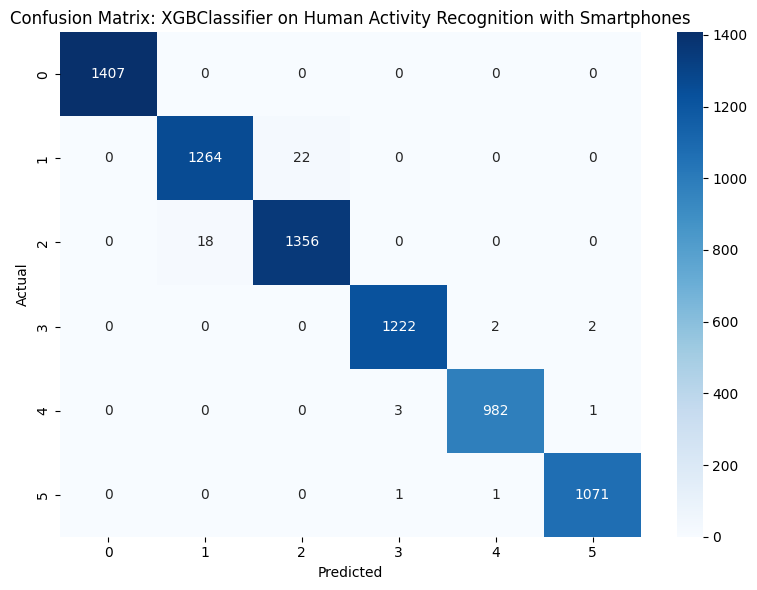

<Axes: >

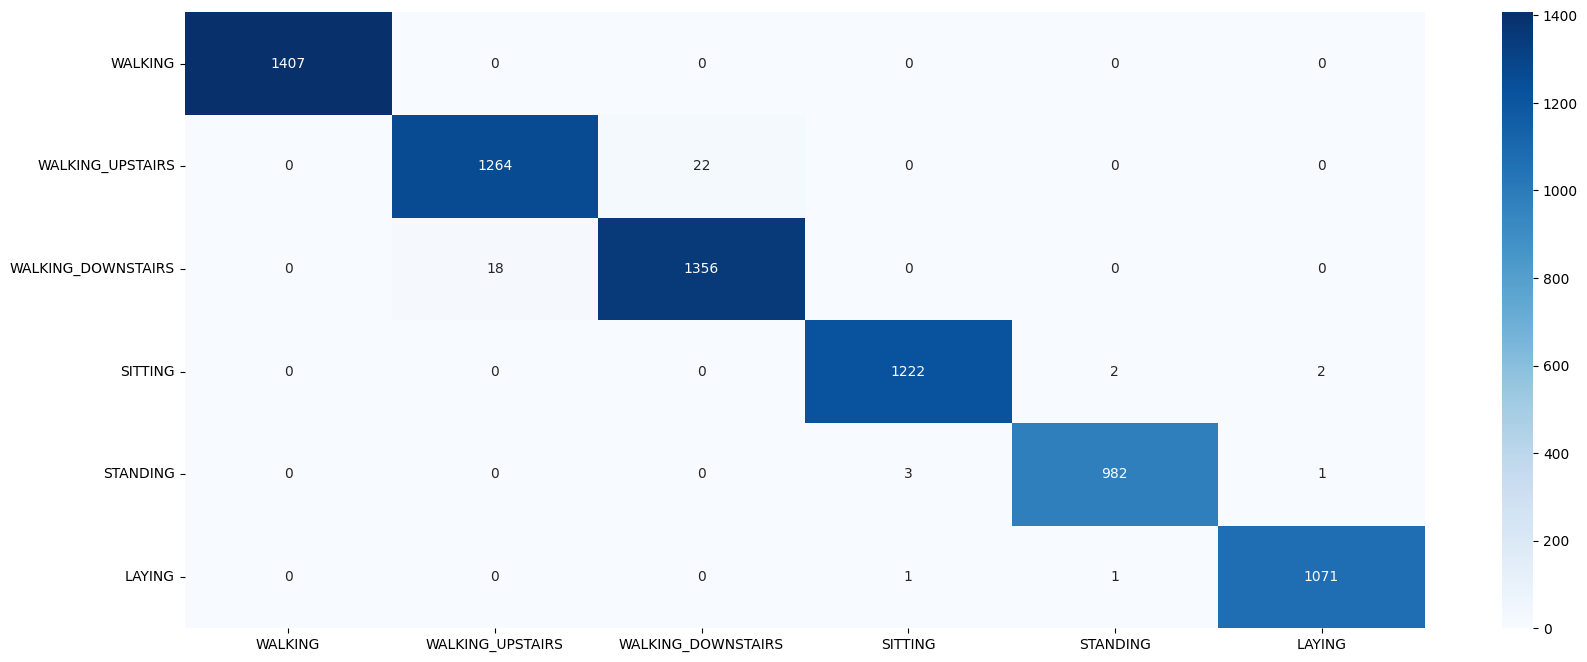

In [58]:
dataset_name = "Human Activity Recognition with Smartphones"
model_name = "XGBClassifier"

conf_matrix = results[dataset_name][model_name]["confusion_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {model_name} on {dataset_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

class_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

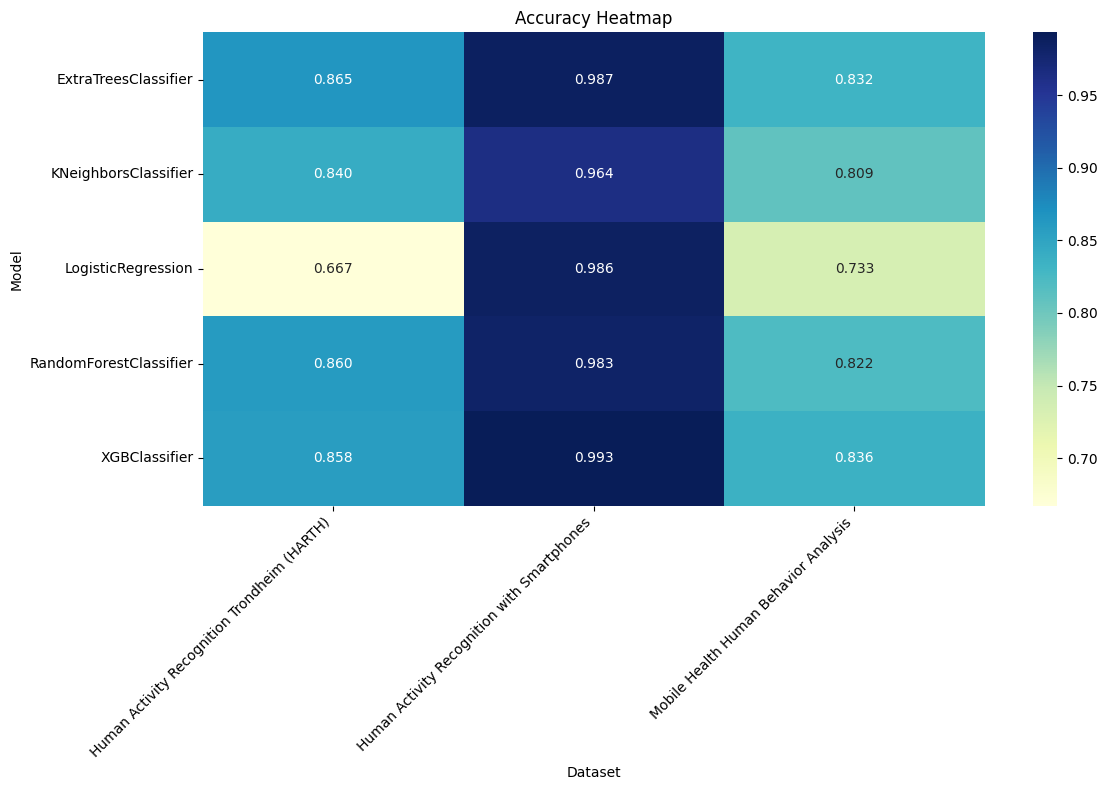

In [59]:
def heatmap_results(results):
    # Create a DataFrame from the dictionary
    data = []
    for dataset, models in results.items():
        for model, metrics in models.items():
            data.append({'Dataset': dataset, 'Model': model, **metrics})
    
    df = pd.DataFrame(data)
    metrics = ['accuracy']# , 'f1', 'auc']
    
    for metric in metrics:
        pivot_table = df.pivot(index='Model', columns='Dataset', values=metric)
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="YlGnBu")
        plt.title(f'{metric.capitalize()} Heatmap')
        plt.ylabel('Model')
        plt.xlabel('Dataset')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

heatmap_results(results)

c:\Users\AsusTUF\anaconda3\envs\tru_HAR\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\AsusTUF\anaconda3\envs\tru_HAR\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Figure size 1000x600 with 0 Axes>

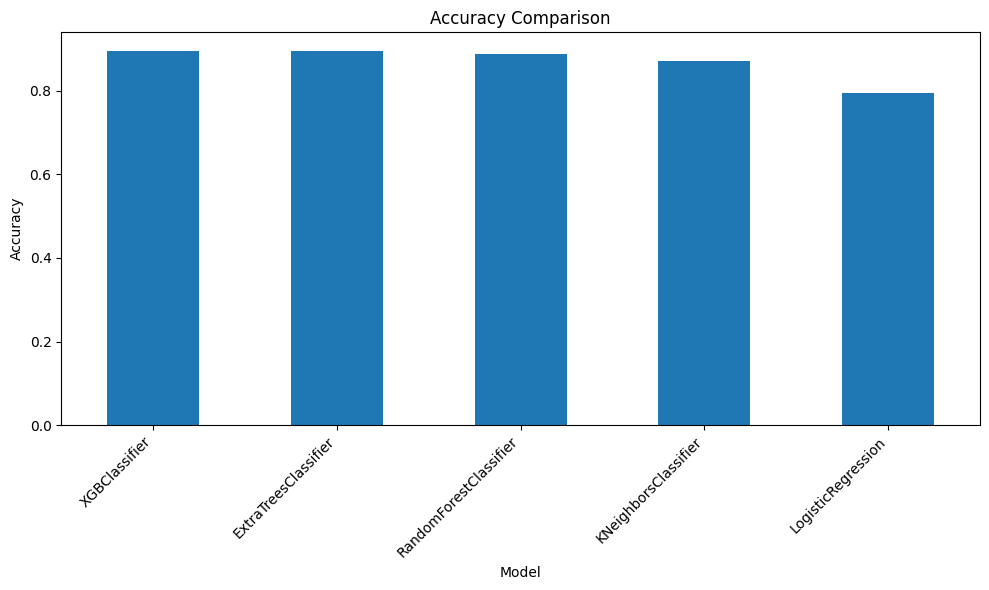

<Figure size 1000x600 with 0 Axes>

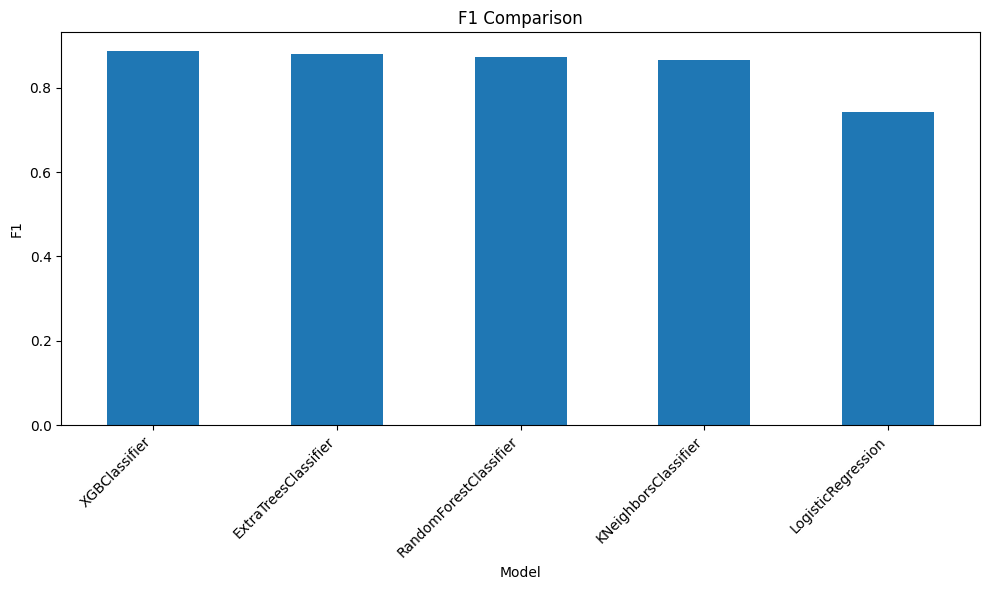

<Figure size 1000x600 with 0 Axes>

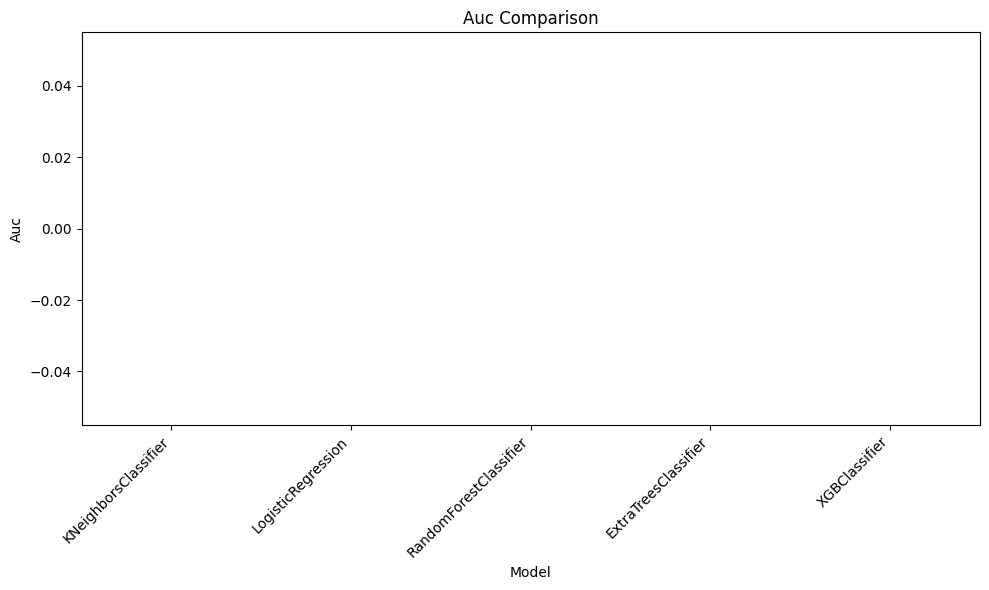

In [60]:
def bar_chart_results(results):
    df = average_metrics(results)
    metrics = ['accuracy', 'f1', 'auc']
    
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        df.sort_values(by=metric, ascending=False).plot(
            x='Model', y=metric, kind='bar', legend=False, figsize=(10, 6), title=f'{metric.capitalize()} Comparison'
        )
        plt.ylabel(metric.capitalize())
        plt.xlabel('Model')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

bar_chart_results(results)


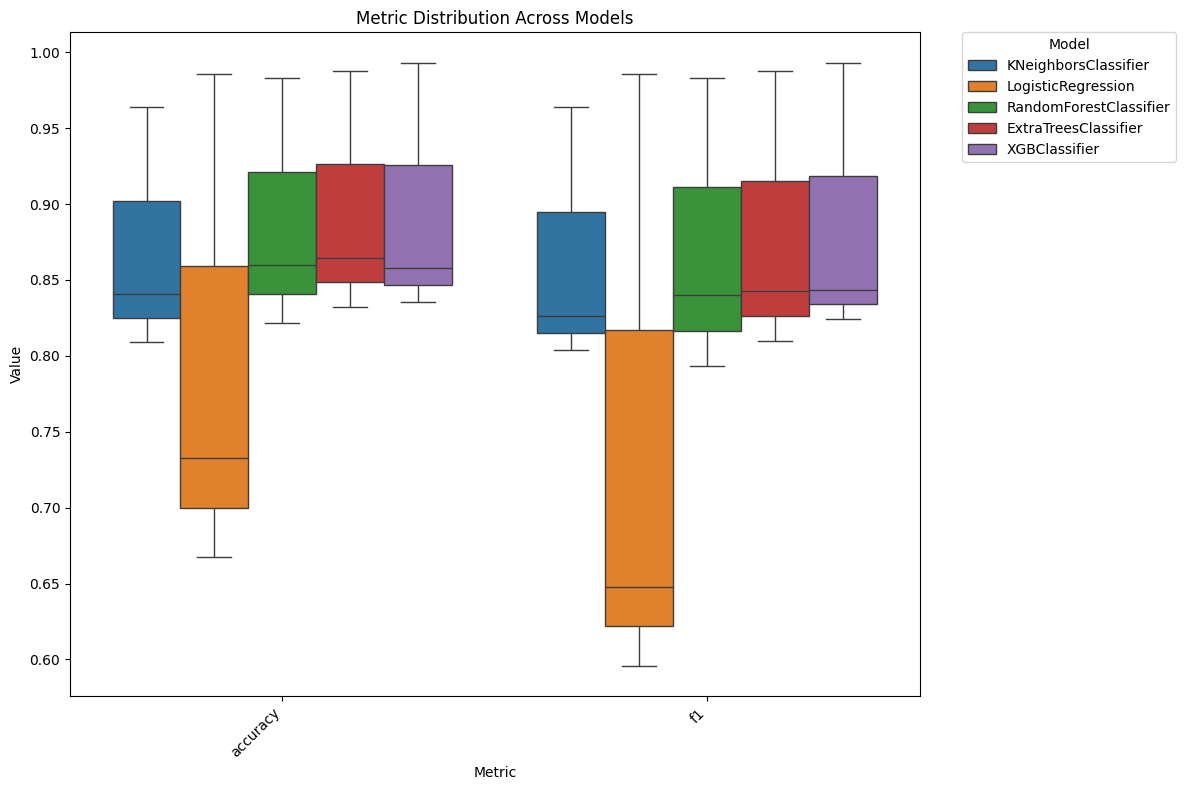

In [62]:
def box_plot_results(results):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    data = []
    for dataset, models in results.items():
        for model, metrics in models.items():
            for metric, value in metrics.items():
                if metric != "confusion_matrix":  # Skip non-scalar metric
                    data.append({
                        'Metric': metric,
                        'Value': value,
                        'Model': model,
                        'Dataset': dataset
                    })

    df = pd.DataFrame(data)

    plt.figure(figsize=(12, 8))
    sns.boxplot(x='Metric', y='Value', hue='Model', data=df)
    plt.title('Metric Distribution Across Models')
    plt.ylabel('Value')
    plt.xlabel('Metric')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

box_plot_results(results)

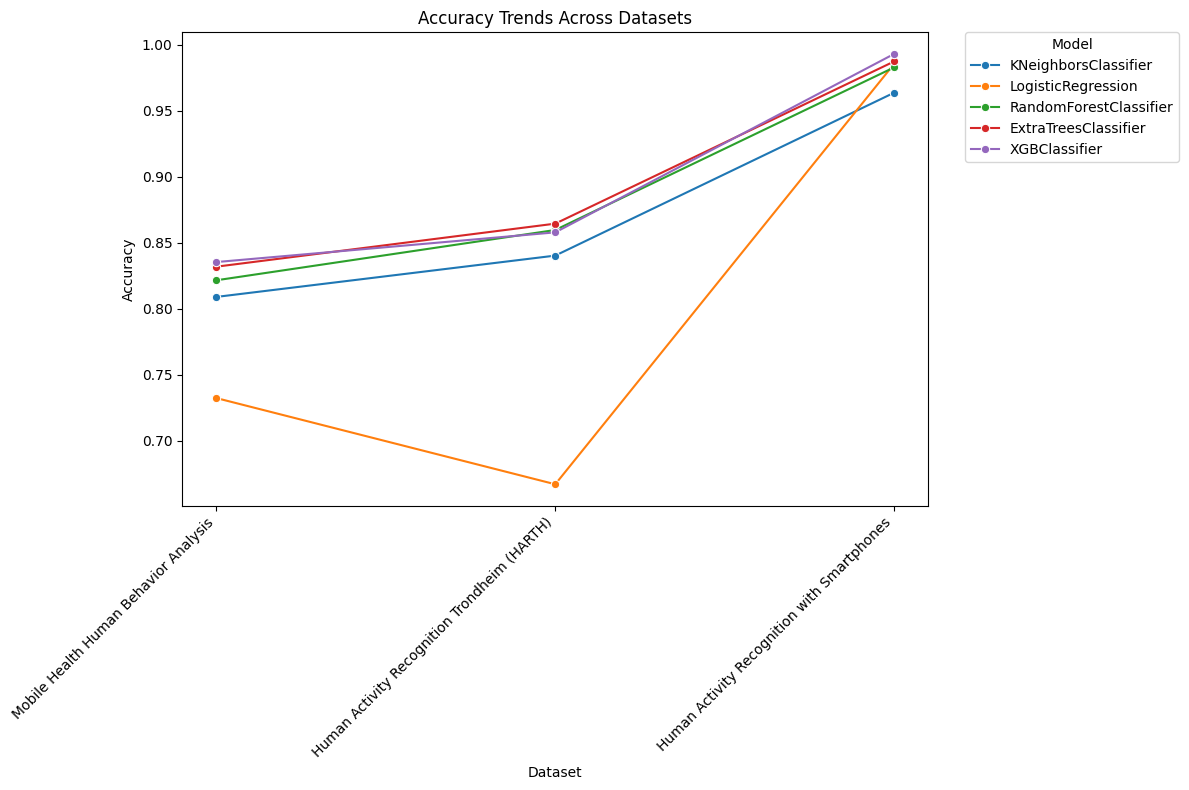

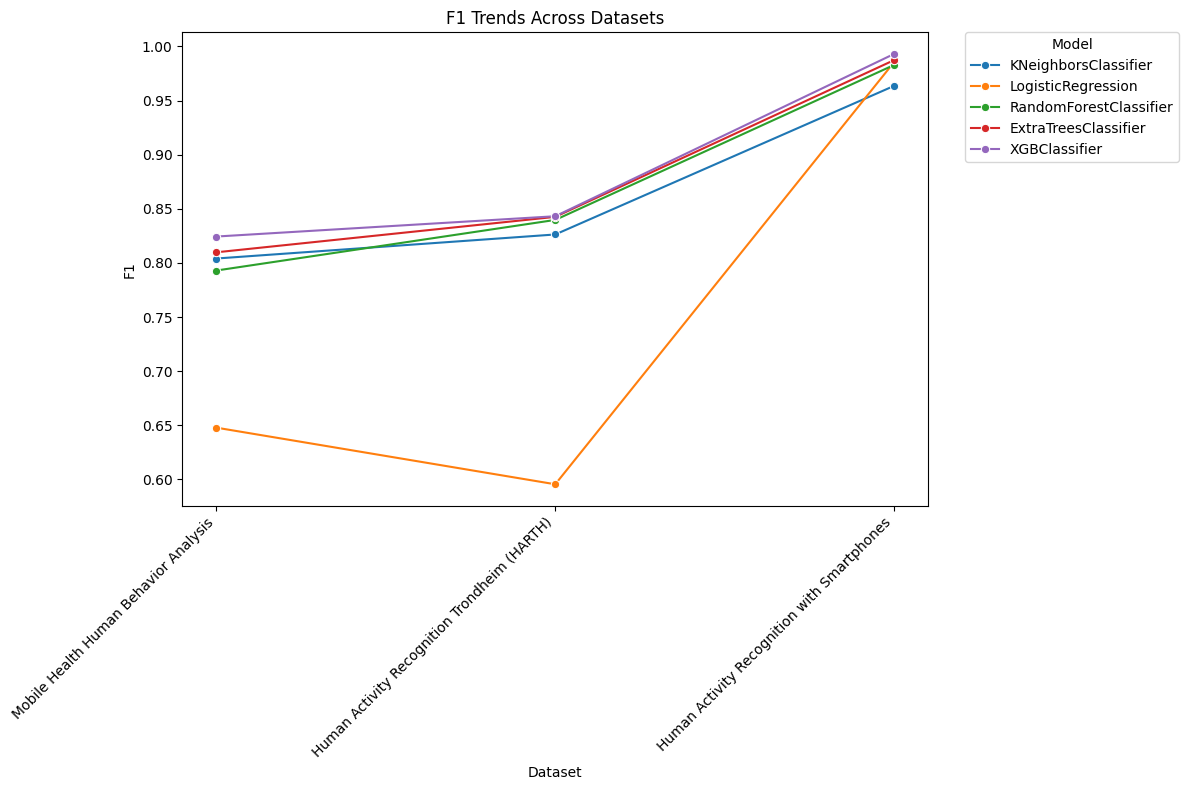

C:\Users\AsusTUF\AppData\Local\Temp\ipykernel_14700\2764278313.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


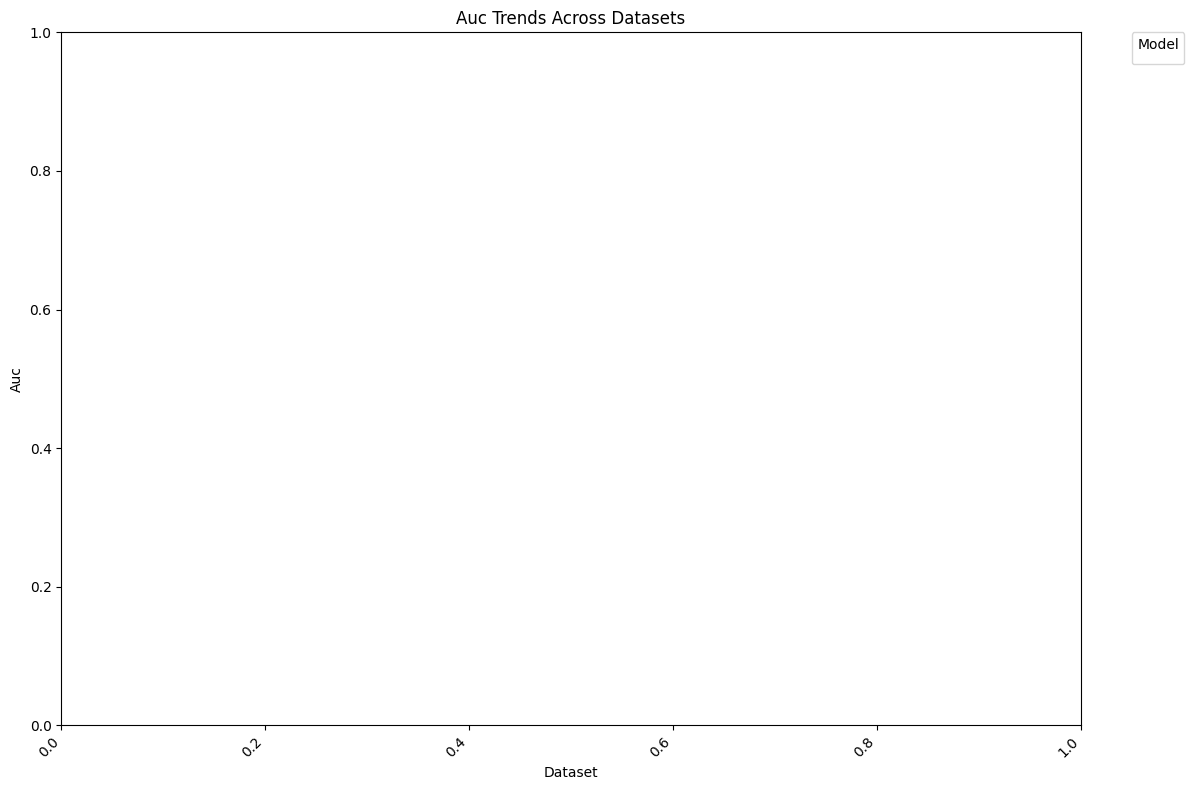

In [63]:
def line_chart_results(results):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # Create a DataFrame from the dictionary
    data = []
    for dataset, models in results.items():
        for model, metrics in models.items():
            for metric, value in metrics.items():
                data.append({'Dataset': dataset, 'Metric': metric, 'Value': value, 'Model': model})
    
    df = pd.DataFrame(data)
    metrics = ['accuracy', 'f1', 'auc']
    
    for metric in metrics:
        plt.figure(figsize=(12, 8))
        sns.lineplot(x='Dataset', y='Value', hue='Model', data=df[df['Metric'] == metric], marker='o')
        plt.title(f'{metric.capitalize()} Trends Across Datasets')
        plt.ylabel(metric.capitalize())
        plt.xlabel('Dataset')
        plt.xticks(rotation=45, ha='right')
        # Move legend outside
        plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.tight_layout()
        plt.show()

line_chart_results(results)